In [1]:
import modules.data as d
import modules.utils as u
from pathlib import Path

#### init ####
dataset_dir = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')
device = u.Devices().auto_set_device(drop=['cuda:4'])

#### data ####
brca = d.TCGA(
    tcga_project = 'BRCA',
    tcga_dir = dataset_dir/'tcga',
    # type_col = 'sample_type',
    subtype_col = 'paper_BRCA_Subtype_PAM50',
    drop = ['Normal', 'Primary Tumor', 'Metastatic'],
    gene_name_path = dataset_dir/'other'/'name2ensg.csv',
    keep_noname = False,
)

kegg = d.KEGG(
    relation_filepath=dataset_dir/'other'/'relation_ohe.csv', 
    counts_data=brca,
)

dataset = d.GraphDataset(brca, kegg, kegg)
_batch = d.get_toy_databatch(dataset, device)

('cuda:7', 'NVIDIA A100-SXM4-80GB', 81041)
('cuda:0', 'NVIDIA A100-SXM4-80GB', 78102)
('cuda:5', 'NVIDIA A100-SXM4-80GB', 74623)
('cuda:6', 'NVIDIA A100-SXM4-80GB', 60915)
('cuda:4', 'NVIDIA A100-SXM4-80GB', 53083)
('cuda:1', 'NVIDIA A100-SXM4-80GB', 52273)
('cuda:2', 'NVIDIA A100-SXM4-80GB', 11225)
('cuda:3', 'NVIDIA A100-SXM4-80GB', 10521)

# #### Device() ####
# device = cuda:7

# #### KEGG() ####
# _orig_kwargs             5                        dict
# relation                 (75939, 19)              DataFrame
# ensg                     4373                     list
# pathway_labels           305                      list
# edge_index               (2, 32464)               Tensor (cuda:7)
# edge_attr                (32464, 16)              Tensor (cuda:7)
# edge_labels              16                       list
# pathway_index            (4373, 305)              Tensor (cuda:7)

# #### TCGA() ####
# _orig_kwargs             9                        dict
# counts_path            

---

In [2]:
from modules.layers import AttentionSetPooling
from modules.model import MultiLatentModel
from modules.norm import LogCounts
from modules.train import MultiTrainer, MultiTrainerStage, Experiment, grid, Loader
from modules.trainers import ReconstrTrainer, ClassifTrainer
from modules.loss import NBLoss, KLDLoss, MultiLoss

import torch
import torch.nn as nn
from functools import partial

In [3]:
# loader
loader = Loader(
    dataset,
    device=device,
    batch_size=128,
)
# multihead model
model = MultiLatentModel(
    dataset = dataset,
    embed_dim = 128,
    # head_dim = None (default)
    # num_heads = 1 (default)
    method = 'set',

    # layers
    norm_class = LogCounts,
    encoder_class = nn.Linear,
    pooling_class = AttentionSetPooling,
    mlp = False,
    variational = True,
    # out_module = nn.Linear (default)

    # layer params
    hidden_dims = 1,
    act_fn = nn.ReLU, 
    norm_fn = 'layer', 
    end_fn = False,

    # kwargs
    norm_kwargs = {'libnorm':True, 'znorm':True, 'learnable':True}
    # pooling_kwargs = None (default)
)

# load state dict
model.init_with_loader(loader) # this is required to init params before state dict
state_dict = torch.load('output/2026-01-20_18h51m04s_benchmark_2_attn/pathway_vae/pathway_vae_trial_0_model.pth', map_location=device)
model.load_state_dict(state_dict)
model.eval()

MultiLatentModel(
  (encoder): Encoder(
    (norm): LogCounts()
    (node_encoder): Sequential(
      (layers): ModuleList(
        (0): Linear(in_features=1, out_features=128, bias=True)
        (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (2): ReLU()
        (3): Linear(in_features=128, out_features=128, bias=True)
      )
    )
    (node_pooling): AttentionSetPooling(
      (lin): Sequential(
        (layers): ModuleList(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (2): ReLU()
          (3): Linear(in_features=128, out_features=305, bias=True)
        )
      )
    )
  )
  (latent_ae): Latent(
    (pooling): AttentionSetPooling(
      (lin): Sequential(
        (layers): ModuleList(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (2): ReLU()
          (3): Linear

---

In [4]:
from torch_geometric.loader import DataLoader
from modules.data import GraphDataset
from modules.utils import dict_summary
from collections import defaultdict
import seaborn as sns
import pandas as pd

# typing
from torch import Tensor
from torch_geometric.data import Data, Batch


In [5]:
class ModelOut2():
    def __init__(self, model:nn.Module, dataset:GraphDataset, batch_size:int=64, **fwd_kwargs):
        fwd_kwargs = fwd_kwargs if fwd_kwargs is not None else {}

        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

        x_list = []
        y_list = []
        out_list = []

        for batch in loader:
            out = model(batch, **fwd_kwargs)
            out = self._detach_items(out)
            out_list.append(out)
            x_list.append(batch.x)
            y_list.append(batch.y)

        self.x = torch.cat(x_list, dim=0).reshape(-1, dataset.wrapper.num_nodes).cpu()
        self.y = torch.cat(y_list, dim=0).cpu()
        self.out = self._transpose_values(out_list)

    def _detach_items(self, item):
        # single tensor
        if isinstance(item, Tensor):
            return item.detach().cpu()

        # list/tuple (recursive)
        if isinstance(item, (list, tuple, set)):
            return type(item)(self._detach_items(i) for i in item)

        # dict, PyG Data/DataBatch
        if isinstance(item, (dict, Data, Batch)):
            return {key: self._detach_items(value) for key, value in item.items()}
        
        # other class with .x
        if hasattr(item, 'x'):
            return {
                'x': self._detach_items(item.x),
                'y': self._detach_items(getattr(item, 'y', None)),
                'sample_id': self._detach_items(getattr(item, 'sample_id', None))
            }
        
        # fallback
        return item

    def _transpose_values(self, values) -> dict:
        out = defaultdict(list)

        # collect
        for v in values:
            for k, val in v.items():
                out[k].append(val)

        # concat if tensor
        for k, vals in out.items():
            v0 = vals[0]

            if torch.is_tensor(v0):
                if v0.ndim == 0: # scalar tensor -> stack
                    out[k] = torch.stack(vals, dim=0)

                # elif v0.ndim == 1: # vector tensor -> concat

                else: # batched tensor -> concat on batch dim
                    out[k] = torch.cat(vals, dim=0)
            
            elif isinstance(v0, dict): # dict -> recursively concat
                out[k] = self._transpose_values(vals)

            else:
                out[k] = vals

        return dict(out)




In [6]:
vals = ModelOut2(model, dataset, need_weights=True)

In [7]:
print(dict_summary(vals.out))

# x                        (1172, 4373)             Tensor (cpu)
# x_t                      (1172, 4373)             Tensor (cpu)
# libsize                  (1172,)                  Tensor (cpu)
# libscale                 (19,)                    Tensor (cpu)
# batch_size               19                       list
# num_nodes                19                       list
# layer_outs               6                        dict
# h_node                   (1172, 4373, 128)        Tensor (cpu)
# h_pool                   (1172, 305, 128)         Tensor (cpu)
# theta                    (19, 4373)               Tensor (cpu)
# z_mu_ae                  (1172, 128)              Tensor (cpu)
# z_logvar_ae              (1172, 128)              Tensor (cpu)
# z_ae                     (1172, 128)              Tensor (cpu)
# z_mu_cl                  (1172, 128)              Tensor (cpu)
# z_logvar_cl              (1172, 128)              Tensor (cpu)
# z_cl                     (1172, 128)           

In [10]:
vals.y

tensor([2, 2, 2,  ..., 3, 1, 2])

In [11]:
vals.out['layer_outs']['np']['attn'].shape

torch.Size([1172, 4373, 305])

In [12]:
print(dict_summary(vals.out['layer_outs']))

# ne                       0                        dict
# np                       1                        dict
# lp_ae                    1                        dict
# lp_cl                    1                        dict
# out_ae                   0                        dict
# out_cl                   0                        dict



In [13]:
d = vals.out['layer_outs']['np']['attn']
d2ae = vals.out['layer_outs']['lp_ae']['attn'].squeeze()
d2cl = vals.out['layer_outs']['lp_cl']['attn'].squeeze()

<Axes: >

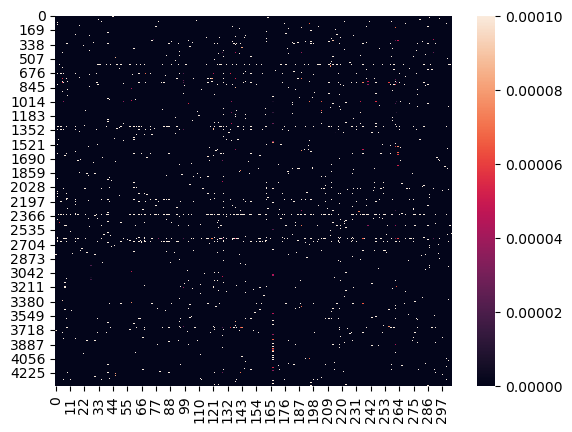

In [14]:
sns.heatmap(d[0], vmax=0.0001)

In [15]:
d2ae.shape

torch.Size([1172, 305])

<Axes: >

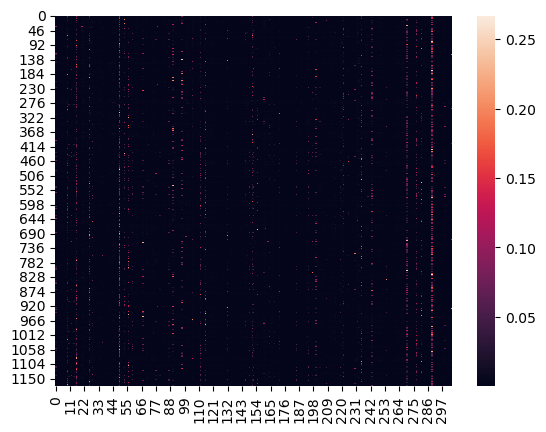

In [17]:
sns.heatmap(d2cl)

In [51]:
def split_by_class(x, cls):
    out = {int(c): x[cls == c].mean(dim=0).tolist() for c in cls.unique()}
    out['Total'] = x.mean(dim=0).tolist()
    return out

In [52]:
ae = split_by_class(d2ae, vals.y)
cl = split_by_class(d2cl, vals.y)

In [53]:
ae = pd.DataFrame(ae)
ae.columns = dataset.wrapper.y_labels + ['Total']
ae

,Basal,Her2,LumA,LumB,Solid Tissue Normal,Total
0,0.002514,0.002580,0.002729,0.002736,0.002761,0.002687
1,0.003507,0.003504,0.003532,0.003519,0.003576,0.003528
2,0.002894,0.002930,0.002967,0.002921,0.002894,0.002937
3,0.003497,0.003490,0.003520,0.003499,0.003596,0.003517
4,0.003506,0.003506,0.003524,0.003514,0.003599,0.003525
...,...,...,...,...,...,...
300,0.003495,0.003491,0.003534,0.003502,0.003566,0.003522
301,0.002645,0.002710,0.002857,0.002707,0.002517,0.002752
302,0.003506,0.003492,0.003374,0.003475,0.003436,0.003428
303,0.003503,0.003499,0.003552,0.003514,0.003605,0.003538


In [54]:
cl = pd.DataFrame(ae)
cl.columns = dataset.wrapper.y_labels + ['Total']
cl

,Basal,Her2,LumA,LumB,Solid Tissue Normal,Total
0,0.002514,0.002580,0.002729,0.002736,0.002761,0.002687
1,0.003507,0.003504,0.003532,0.003519,0.003576,0.003528
2,0.002894,0.002930,0.002967,0.002921,0.002894,0.002937
3,0.003497,0.003490,0.003520,0.003499,0.003596,0.003517
4,0.003506,0.003506,0.003524,0.003514,0.003599,0.003525
...,...,...,...,...,...,...
300,0.003495,0.003491,0.003534,0.003502,0.003566,0.003522
301,0.002645,0.002710,0.002857,0.002707,0.002517,0.002752
302,0.003506,0.003492,0.003374,0.003475,0.003436,0.003428
303,0.003503,0.003499,0.003552,0.003514,0.003605,0.003538


In [55]:
import pandas as pd
pnames = pd.read_csv(dataset_dir/'other'/'pathway_names.csv')

In [56]:
pnames

,entry,name
0,hsa01100,Metabolic pathways - Homo sapiens (human)
1,hsa01200,Carbon metabolism - Homo sapiens (human)
2,hsa01210,2-Oxocarboxylic acid metabolism - Homo sapiens...
3,hsa01212,Fatty acid metabolism - Homo sapiens (human)
4,hsa01230,Biosynthesis of amino acids - Homo sapiens (hu...
...,...,...
361,hsa04934,Cushing syndrome - Homo sapiens (human)
362,hsa01521,EGFR tyrosine kinase inhibitor resistance - Ho...
363,hsa01524,Platinum drug resistance - Homo sapiens (human)
364,hsa01523,Antifolate resistance - Homo sapiens (human)


In [57]:
plabels = [s.replace('path:', '') for s in dataset.wrapper.pathway_labels]

In [58]:
plabels

['hsa04975',
 'hsa04010',
 'hsa04630',
 'hsa05030',
 'hsa05210',
 'hsa04137',
 'hsa05169',
 'hsa04114',
 'hsa05205',
 'hsa04520',
 'hsa05320',
 'hsa04666',
 'hsa00280',
 'hsa04672',
 'hsa05330',
 'hsa04068',
 'hsa05412',
 'hsa04668',
 'hsa00520',
 'hsa04061',
 'hsa00750',
 'hsa00563',
 'hsa05321',
 'hsa04613',
 'hsa00592',
 'hsa04979',
 'hsa04340',
 'hsa00240',
 'hsa04614',
 'hsa00030',
 'hsa00565',
 'hsa05222',
 'hsa04934',
 'hsa04911',
 'hsa04976',
 'hsa05417',
 'hsa04122',
 'hsa00630',
 'hsa00440',
 'hsa04915',
 'hsa04360',
 'hsa04371',
 'hsa05110',
 'hsa03018',
 'hsa00100',
 'hsa00670',
 'hsa00330',
 'hsa05031',
 'hsa05322',
 'hsa04512',
 'hsa05034',
 'hsa04964',
 'hsa04622',
 'hsa05150',
 'hsa00400',
 'hsa04978',
 'hsa04610',
 'hsa04072',
 'hsa00760',
 'hsa04740',
 'hsa04910',
 'hsa05016',
 'hsa04714',
 'hsa05203',
 'hsa05226',
 'hsa04916',
 'hsa04012',
 'hsa00980',
 'hsa04015',
 'hsa05212',
 'hsa00920',
 'hsa05332',
 'hsa01523',
 'hsa05213',
 'hsa04723',
 'hsa04612',
 'hsa04213',

In [59]:
pnames

,entry,name
0,hsa01100,Metabolic pathways - Homo sapiens (human)
1,hsa01200,Carbon metabolism - Homo sapiens (human)
2,hsa01210,2-Oxocarboxylic acid metabolism - Homo sapiens...
3,hsa01212,Fatty acid metabolism - Homo sapiens (human)
4,hsa01230,Biosynthesis of amino acids - Homo sapiens (hu...
...,...,...
361,hsa04934,Cushing syndrome - Homo sapiens (human)
362,hsa01521,EGFR tyrosine kinase inhibitor resistance - Ho...
363,hsa01524,Platinum drug resistance - Homo sapiens (human)
364,hsa01523,Antifolate resistance - Homo sapiens (human)


In [60]:
pathway_names = pnames.set_index('entry').loc[plabels, 'name'].to_list()
pathway_names = [s.replace(' - Homo sapiens (human)', '') for s in pathway_names]

In [61]:
ae.index = pathway_names
ae

,Basal,Her2,LumA,LumB,Solid Tissue Normal,Total
Fat digestion and absorption,0.002514,0.002580,0.002729,0.002736,0.002761,0.002687
MAPK signaling pathway,0.003507,0.003504,0.003532,0.003519,0.003576,0.003528
JAK-STAT signaling pathway,0.002894,0.002930,0.002967,0.002921,0.002894,0.002937
Cocaine addiction,0.003497,0.003490,0.003520,0.003499,0.003596,0.003517
Colorectal cancer,0.003506,0.003506,0.003524,0.003514,0.003599,0.003525
...,...,...,...,...,...,...
B cell receptor signaling pathway,0.003495,0.003491,0.003534,0.003502,0.003566,0.003522
Pyruvate metabolism,0.002645,0.002710,0.002857,0.002707,0.002517,0.002752
"Parathyroid hormone synthesis, secretion and action",0.003506,0.003492,0.003374,0.003475,0.003436,0.003428
Glucagon signaling pathway,0.003503,0.003499,0.003552,0.003514,0.003605,0.003538


In [62]:
cl.index = pathway_names
cl

,Basal,Her2,LumA,LumB,Solid Tissue Normal,Total
Fat digestion and absorption,0.002514,0.002580,0.002729,0.002736,0.002761,0.002687
MAPK signaling pathway,0.003507,0.003504,0.003532,0.003519,0.003576,0.003528
JAK-STAT signaling pathway,0.002894,0.002930,0.002967,0.002921,0.002894,0.002937
Cocaine addiction,0.003497,0.003490,0.003520,0.003499,0.003596,0.003517
Colorectal cancer,0.003506,0.003506,0.003524,0.003514,0.003599,0.003525
...,...,...,...,...,...,...
B cell receptor signaling pathway,0.003495,0.003491,0.003534,0.003502,0.003566,0.003522
Pyruvate metabolism,0.002645,0.002710,0.002857,0.002707,0.002517,0.002752
"Parathyroid hormone synthesis, secretion and action",0.003506,0.003492,0.003374,0.003475,0.003436,0.003428
Glucagon signaling pathway,0.003503,0.003499,0.003552,0.003514,0.003605,0.003538


In [71]:
ae.sort_values(by='Solid Tissue Normal', ascending=False)

,Basal,Her2,LumA,LumB,Solid Tissue Normal,Total
Rheumatoid arthritis,0.003395,0.003137,0.003210,0.003125,0.003692,0.003267
Salmonella infection,0.003509,0.003501,0.003585,0.003517,0.003622,0.003558
Efferocytosis,0.003505,0.003503,0.003583,0.003518,0.003618,0.003556
Pyrimidine metabolism,0.003500,0.003488,0.003562,0.003501,0.003616,0.003541
Cellular senescence,0.003507,0.003501,0.003583,0.003517,0.003616,0.003556
...,...,...,...,...,...,...
Renin-angiotensin system,0.002387,0.002551,0.002548,0.002497,0.002306,0.002489
Drug metabolism - cytochrome P450,0.002439,0.002540,0.002589,0.002586,0.002303,0.002532
Rap1 signaling pathway,0.002406,0.002609,0.002662,0.002659,0.002294,0.002579
Aldosterone-regulated sodium reabsorption,0.002538,0.002795,0.002663,0.002666,0.002281,0.002615


In [72]:
cl.sort_values(by='Total', ascending=False)

,Basal,Her2,LumA,LumB,Solid Tissue Normal,Total
Autophagy - animal,0.003511,0.003503,0.003586,0.003518,0.003615,0.003558
Salmonella infection,0.003509,0.003501,0.003585,0.003517,0.003622,0.003558
Efferocytosis,0.003505,0.003503,0.003583,0.003518,0.003618,0.003556
Cellular senescence,0.003507,0.003501,0.003583,0.003517,0.003616,0.003556
Pathways of neurodegeneration - multiple diseases,0.003506,0.003499,0.003583,0.003519,0.003611,0.003555
...,...,...,...,...,...,...
Butanoate metabolism,0.002368,0.002412,0.002507,0.002425,0.002614,0.002473
Epithelial cell signaling in Helicobacter pylori infection,0.002234,0.002479,0.002549,0.002476,0.002281,0.002452
Glutathione metabolism,0.002254,0.002348,0.002548,0.002431,0.002403,0.002450
Calcium signaling pathway,0.002173,0.002360,0.002417,0.002399,0.002406,0.002368


In [65]:
ae

,Basal,Her2,LumA,LumB,Solid Tissue Normal,Total
Fat digestion and absorption,0.002514,0.002580,0.002729,0.002736,0.002761,0.002687
MAPK signaling pathway,0.003507,0.003504,0.003532,0.003519,0.003576,0.003528
JAK-STAT signaling pathway,0.002894,0.002930,0.002967,0.002921,0.002894,0.002937
Cocaine addiction,0.003497,0.003490,0.003520,0.003499,0.003596,0.003517
Colorectal cancer,0.003506,0.003506,0.003524,0.003514,0.003599,0.003525
...,...,...,...,...,...,...
B cell receptor signaling pathway,0.003495,0.003491,0.003534,0.003502,0.003566,0.003522
Pyruvate metabolism,0.002645,0.002710,0.002857,0.002707,0.002517,0.002752
"Parathyroid hormone synthesis, secretion and action",0.003506,0.003492,0.003374,0.003475,0.003436,0.003428
Glucagon signaling pathway,0.003503,0.003499,0.003552,0.003514,0.003605,0.003538


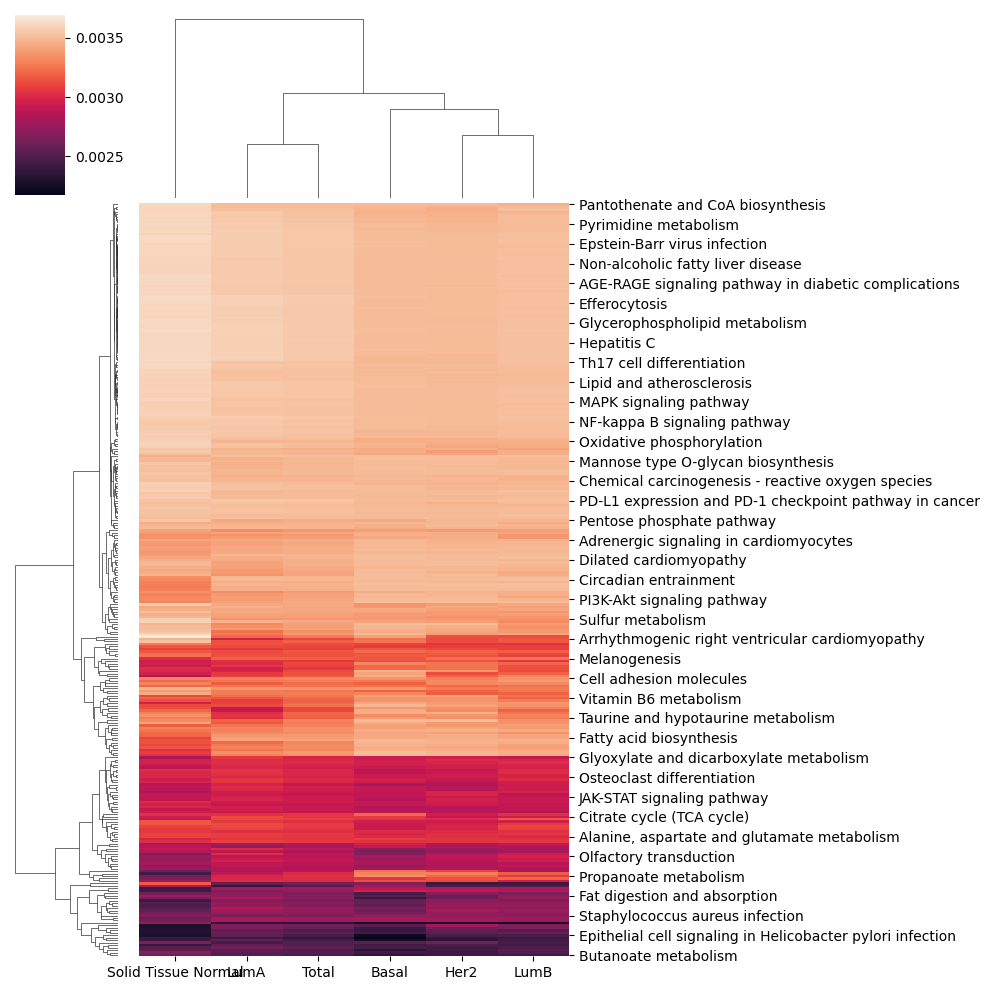

In [73]:
sns.clustermap(ae)

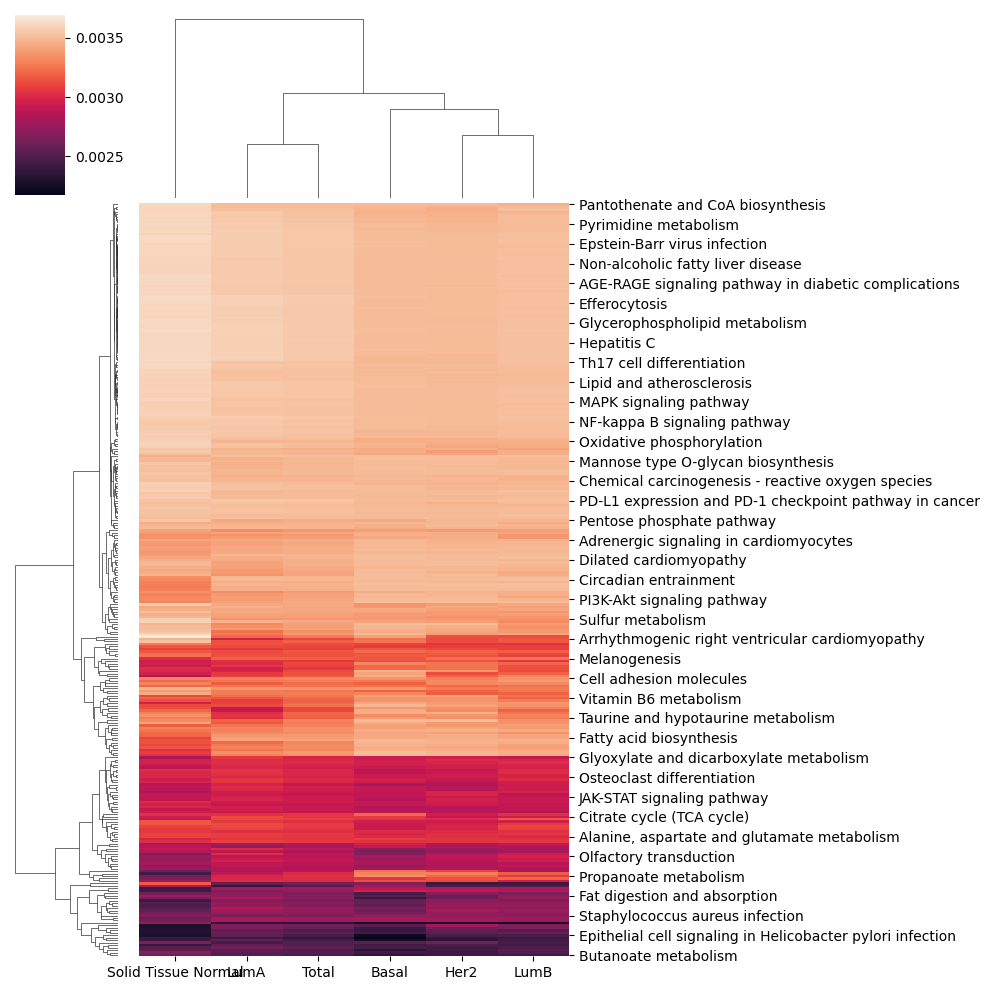

In [74]:
sns.clustermap(cl)

In [68]:
d.shape

torch.Size([1172, 4373, 305])

In [75]:
vals.y

tensor([2, 2, 2,  ..., 3, 1, 2])

In [117]:
def split_by_class(x, cls):
    out = {int(c): x[cls == c].mean(dim=0).mean(dim=1).tolist() for c in cls.unique()}
    out['Total'] = x.mean(dim=0).mean(dim=1).tolist()
    return out

In [118]:
n2s = split_by_class(d, vals.y)
n2s

{0: [5.698707809642656e-06,
  0.0001247398613486439,
  3.6486333556240425e-05,
  4.0407918277196586e-05,
  0.0003257593489252031,
  9.620394848752767e-05,
  3.244174149585888e-05,
  0.0014547404134646058,
  0.00011128705955343321,
  0.00028310943162068725,
  1.759959923219867e-05,
  0.00016292408690787852,
  3.4199962101411074e-05,
  5.652020263369195e-05,
  2.2896963855600916e-05,
  0.0001220887352246791,
  4.9872574891196564e-05,
  7.721412839600816e-05,
  0.00016221674741245806,
  1.1774894801419578e-06,
  4.32295746577438e-05,
  3.505515633150935e-05,
  4.370299575384706e-05,
  0.00013773466343991458,
  2.5226903744623996e-05,
  0.0003776416997425258,
  3.3033807994797826e-05,
  4.0475657442584634e-05,
  1.1210217962798197e-05,
  0.00027711395523510873,
  3.878996358253062e-05,
  0.001830562949180603,
  6.93247202434577e-05,
  2.949253257611417e-06,
  0.0006687103887088597,
  2.3707847503828816e-05,
  1.4240540622267872e-05,
  2.0482028048718348e-05,
  9.559252794133499e-05,
  0.00

In [120]:
# sns.heatmap(n2s[0], vmax=0.01)

In [121]:
n2s = pd.DataFrame(n2s)
n2s.columns = dataset.wrapper.y_labels + ['Total']
n2s.index = dataset.wrapper.x_labels
n2s

,Basal,Her2,LumA,LumB,Solid Tissue Normal,Total
FGR,0.000006,0.000003,0.000005,0.000010,2.049418e-06,0.000006
GCLC,0.000125,0.000141,0.000140,0.000129,1.087491e-04,0.000133
NFYA,0.000036,0.000045,0.000092,0.000025,2.471953e-04,0.000083
SEMA3F,0.000040,0.000022,0.000016,0.000014,2.984571e-05,0.000022
CFTR,0.000326,0.000435,0.000688,0.000802,2.412561e-04,0.000587
...,...,...,...,...,...,...
ZNF229,0.000003,0.000006,0.000013,0.000011,2.900591e-07,0.000009
ACACA,0.000360,0.000283,0.000428,0.000320,4.004735e-04,0.000385
H3C10,0.000017,0.000010,0.000033,0.000009,1.459163e-04,0.000035
ADORA3,0.000056,0.000062,0.000061,0.000062,6.685468e-05,0.000061


In [129]:
n2s.sort_values(by='Total', ascending=False)

,Basal,Her2,LumA,LumB,Solid Tissue Normal,Total
MAPK3,1.487299e-02,1.334179e-02,1.176753e-02,8.122340e-03,9.773011e-03,1.155732e-02
ADCY9,1.330261e-02,1.478544e-02,7.987767e-03,6.548245e-03,1.463156e-02,9.740603e-03
IKBKB,7.721215e-03,6.953026e-03,5.154619e-03,5.588340e-03,7.967246e-03,6.060390e-03
CASP9,4.580769e-03,4.954348e-03,6.324078e-03,5.332729e-03,4.729090e-03,5.604645e-03
MAPK8,3.847665e-03,7.502446e-03,6.348857e-03,5.417753e-03,3.368176e-03,5.555719e-03
...,...,...,...,...,...,...
ZNF530,1.026705e-06,1.583353e-07,1.170640e-06,7.002527e-07,4.789818e-07,9.250491e-07
ZNF641,1.343838e-06,3.009497e-06,6.267551e-07,4.047257e-07,2.670158e-07,8.397205e-07
ZNF184,7.646915e-07,3.766084e-07,8.727145e-07,3.834096e-07,1.644970e-06,8.070480e-07
ZFP90,1.636320e-06,1.039294e-06,5.443512e-07,5.648720e-07,3.079282e-07,7.433924e-07


/home/mv18gs/miniconda3/envs/thesis_pyg/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/mv18gs/miniconda3/envs/thesis_pyg/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


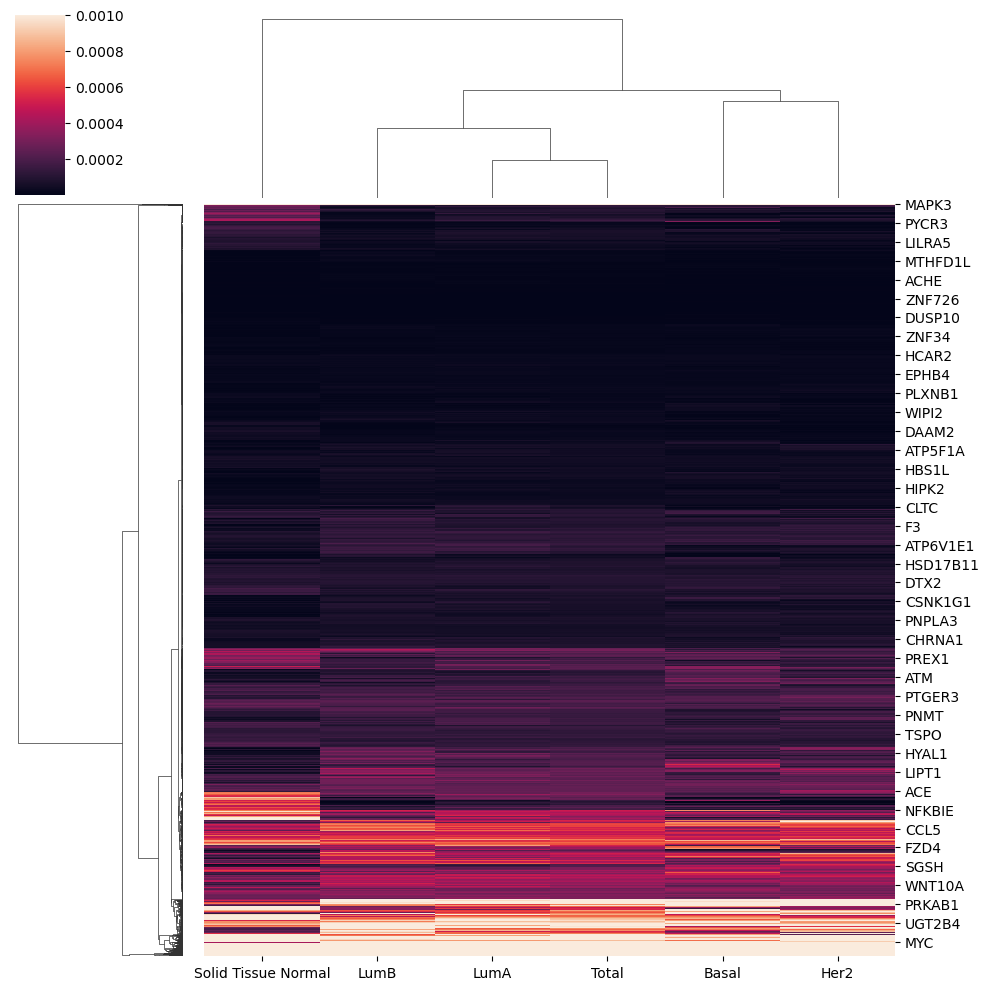

In [128]:
sns.clustermap(n2s, vmax=0.001)

In [107]:
dataset.wrapper.x_labels


['FGR',
 'GCLC',
 'NFYA',
 'SEMA3F',
 'CFTR',
 'CYP51A1',
 'KRIT1',
 'BAD',
 'LAP3',
 'AOC1',
 'M6PR',
 'CYP26B1',
 'ALS2',
 'CASP10',
 'CFLAR',
 'MTMR7',
 'SARM1',
 'AK2',
 'CD38',
 'KDM1A',
 'CAMKK1',
 'NDUFAB1',
 'PDK4',
 'CDC27',
 'HCCS',
 'DVL2',
 'UPF1',
 'SLC25A5',
 'DHX33',
 'ACSM3',
 'PRKAR2B',
 'CREBBP',
 'KMT2E',
 'ZNF195',
 'ITGAL',
 'PDK2',
 'ITGA3',
 'LAMP2',
 'ITGA2B',
 'MAP3K14',
 'ABCC8',
 'AP2B1',
 'CX3CL1',
 'CACNA1G',
 'TNFRSF12A',
 'MAP3K9',
 'RALA',
 'AGK',
 'ALDH3B1',
 'FARP2',
 'GGCT',
 'TBXA2R',
 'COX10',
 'VPS41',
 'SCIN',
 'PNPLA4',
 'ADIPOR2',
 'PAFAH1B1',
 'DNAH9',
 'MATK',
 'CD79B',
 'RHBDF1',
 'CACNA2D2',
 'TEAD3',
 'SELE',
 'FMO3',
 'MYLIP',
 'NOX1',
 'E2F2',
 'PSMB1',
 'NADK',
 'CYTH3',
 'AASS',
 'MGST1',
 'ST3GAL1',
 'MMP25',
 'MAPK8IP2',
 'MASP2',
 'POMT2',
 'VTA1',
 'MLXIPL',
 'UQCRC1',
 'GIPR',
 'SEMA3G',
 'STAB1',
 'IDS',
 'ZNF200',
 'CD4',
 'BTK',
 'HFE',
 'FYN',
 'FMO1',
 'LYPLA2',
 'MRC2',
 'ABHD5',
 'PIK3C2A',
 'PLAUR',
 'DCN',
 'PPP5C',
 'MAP4